# Klassifikation und Regression mit der *scikit-learn* Bibliothek

## Klassifikation

Bei einer Klassifikation wird ein Datenpunkt $\mathbf{x}$ einer von $N$ Klassen zugeordnet. Die einzelnen Einträge von $\mathbf{x}$ werden *Features* genannt, $\mathbf{x}$ ist ein *Feature-Vektor*.
<br>
**Zwei Klassen und zwei Features**:
<br>
<img src="2_classes.png" alt="2 Klassen" width="300"/>
<br>
**Drei Klassen und drei Features**:
<br>
<img src="3_classes_3d.png" alt="3 Klassen" width="300"/>

Ein Klassifikator ist eine *Funktion*, die einen Datenpunkt erhält und für diesen eine Klasse ausgibt: 
$$ f(\mathbf{x}) = \text{class}$$
Ziel ist es nun eine *Funktion* $f$ zu finden, die für möglichst alle Datenpunkte die richtige Klasse ausgibt. Dafür gibt es bereits verschiedene Machine Learning Verfahren. Die gängigsten sind in der Python-Bibliothek *scikit-learn* implementiert.  


# Übungsaufgaben

## Dataset: Iris

Verfügbar unter: https://datahub.io/machine-learning/iris/r/iris.csv. Dieser Datensatz enthält 4 Features für 3 verschiedene Spezies (Klassen) der Schwertlilie.

In [1]:
# Load pandas
import pandas as pd

# Plotting library
import seaborn as sns
import matplotlib.pyplot as plt

# render plots in jupyter notebook
%matplotlib inline

## 1. Datensatz einlesen und vorverarbeiten

a) Lies den Datensatz mithilfe von Pandas ein und mach dich mit ihm vertraut. Wie groß ist der Datensatz? Welche Features gibt es?

In [2]:
df = pd.read_csv('iris.csv')
df.head()

,sepallength,sepalwidth,petallength,petalwidth,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sepallength  150 non-null    float64
 1   sepalwidth   150 non-null    float64
 2   petallength  150 non-null    float64
 3   petalwidth   150 non-null    float64
 4   class        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


(150, 5)

In [8]:
df.columns

Index(['sepallength', 'sepalwidth', 'petallength', 'petalwidth', 'class'], dtype='object')

b) Unterteile das DataFrame in die zwei DataFrames ```df_features``` und ```df_class```, die nur die entsprechenden Größen enthalten.

In [9]:
df_class = df[['class']].copy()
df_class.head()

,class
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


In [10]:
df_features = df.drop(columns=['class']).copy()
df_features.head()

,sepallength,sepalwidth,petallength,petalwidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


c) ```df_class``` enthält die Klassen in Form von Strings. Diese Darstellung ist für die nachfolgenden Arbeitsschritte ungeeignet. Bringe das DataFrame ```df_class``` mithilfe von Pandas in folgende Form:<br>
<img src="one_hot_encoded.png" alt="One hot encoded" width="200"/>

**Tipp:** Dieses Darstellung nennt man auch *One Hot Encoding*.

In [13]:
df_class_encoded = pd.get_dummies(df_class, columns=['class'], prefix='class')

df_class_encoded.head()

,class_Iris-setosa,class_Iris-versicolor,class_Iris-virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


d) Um zu überprüfen, ob der Klassifikator fremde Datenpunkte zuordnen kann, muss der Datensatz in ein *Trainingsset* und ein *Testset* unterteilt werden. Der Klassifikator wird auf dem *Trainingsset* trainiert und seine Performace auf dem *Testset* validiert, welches er zuvor nie gesehen hat. So wird sichergestellt, dass er die Datenpunkte nicht "auswendig lernt". 

Teile den Datensatz mithilfe der *scikit-learn*-Bibliothek in *Trainings-* und *Testset* auf. Dabei soll der Trainingsdatensatz 75% der Datenpunkte enthalten.

In [14]:
from sklearn.model_selection import train_test_split

X = df_features
y = df_class_encoded

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Features Training (X_train): {X_train.shape}")
print(f"Features Test (X_test): {X_test.shape}")
print(f"Klassen Training (y_train): {y_train.shape}")
print(f"Klassen Test (y_test): {y_test.shape}")

Features Training (X_train): (112, 4)
Features Test (X_test): (38, 4)
Klassen Training (y_train): (112, 3)
Klassen Test (y_test): (38, 3)


## 2. k-nearest-neighbors

Der *k-nearest-neighbors*-Klassifikator vergleicht einen fremden Datenpunkt mit den $k$ Datenpunkten aus dem *Trainingsset* , welche die kürzeste euklidsche Distanz zu dem neuen Datenpunkt besitzen. Der Datenpunkt erhält dann die Klasse, die der Mehrheit der umliegenden Datenpunkte entspricht. Darum wird $k$ immer ungerade gewählt.

a) Importiere den *k-nearest-neighbors*-Klassifikator aus der *scikit-learn*-Bibliothek und initialisiere eine Instanz des Klassifikators mit 7 nächsten Nachbarn.

In [15]:
from sklearn.neighbors import KNeighborsClassifier

k = 7
knn_classifier = KNeighborsClassifier(n_neighbors=k)

print(f"Der k-NN Klassifikator wurde mit k={k} Nachbarn initialisiert:")
print(knn_classifier)

Der k-NN Klassifikator wurde mit k=7 Nachbarn initialisiert:
KNeighborsClassifier(n_neighbors=7)


b) Trainiere den Klassifikator auf dem Trainingsdatensatz.

In [16]:
knn_classifier.fit(X_train, y_train)

print("Der k-NN Klassifikator wurde erfolgreich auf dem Trainingsdatensatz trainiert.")

Der k-NN Klassifikator wurde erfolgreich auf dem Trainingsdatensatz trainiert.


c) Der Klassifikator kann jetzt einen neuen Datenpunkt erhalten und ihn einer der drei Klassen zuordnen. Wende die ```predict()```-Methode des Klassifikators auf die Test-Datenpunkte an und lass dir das Ergebnis ausgeben.  Was bedeutet die Ausgabe?

In [18]:
y_pred = knn_classifier.predict(X_test)

display(y_pred)

array([[False, False,  True],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [False,  True, False],
       [False,  True, False],
       [False, False,  True],
       [False, False,  True],
       [False, False,  True],
       [False,  True, False],
       [False, False,  True],
       [False,  True, False],
       [ True, False, False],
       [False,  True, False],
       [ True, False, False],
       [False,  True, False],
       [ True, False, False],
       [False,  True, False],
       [False, False,  True],
       [ True, False, False],
       [False, False,  True],
       [False,  True, False],
       [ True, False, False],
       [ True, False, False],
       [False, False,  True],
       [Fa

d) Die Accuracy des Klassifikators kann berechnet werden als 
$ \text{Accuracy} = \frac{\text{Anzahl korrekt klassifizierter Instanzen}}{\text{Anzahl Instanzen}}$.
Berechne die Accuracy auf dem Testdatensatz und überprüfe dein Ergebnis mit der ```score()```-Methode.

In [20]:
import numpy as np
from sklearn.metrics import accuracy_score

comparison_matrix = (y_test.values == y_pred)

display(comparison_matrix)

correct_predictions = comparison_matrix.all(axis=1).sum()

print(correct_predictions)

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True, False, False],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ T

37


In [21]:
total_instances = len(X_test)

manual_accuracy = correct_predictions / total_instances

print(f"Anzahl korrekt klassifizierter Instanzen: {correct_predictions}")
print(f"Gesamtanzahl Instanzen im Testset: {total_instances}")
print(f"Manuell berechnete Accuracy: {manual_accuracy:.4f}")

Anzahl korrekt klassifizierter Instanzen: 37
Gesamtanzahl Instanzen im Testset: 38
Manuell berechnete Accuracy: 0.9737


In [22]:
score_accuracy = knn_classifier.score(X_test, y_test)

print(f"Accuracy mit der score()-Methode: {score_accuracy:.4f}")

Accuracy mit der score()-Methode: 0.9737


e) Verändere die Anzahl an nächsten Nachbarn im Klassifikator und beobachte, wie sich dieser Parameter auf die Accuracy auswirkt.

In [23]:
k_new = 3

knn_classifier_k3 = KNeighborsClassifier(n_neighbors=k_new)

knn_classifier_k3.fit(X_train, y_train)

accuracy_k3 = knn_classifier_k3.score(X_test, y_test)

print(f"--- Testergebnis für k = {k_new} ---")
print(f"Der Klassifikator wurde mit {k_new} Nachbarn trainiert.")
print(f"Accuracy auf dem Testset: {accuracy_k3:.4f}")

--- Testergebnis für k = 3 ---
Der Klassifikator wurde mit 3 Nachbarn trainiert.
Accuracy auf dem Testset: 1.0000


In [24]:
k_new = 13

knn_classifier_k13 = KNeighborsClassifier(n_neighbors=k_new)

knn_classifier_k13.fit(X_train, y_train)

accuracy_k13 = knn_classifier_k3.score(X_test, y_test)

print(f"--- Testergebnis für k = {k_new} ---")
print(f"Der Klassifikator wurde mit {k_new} Nachbarn trainiert.")
print(f"Accuracy auf dem Testset: {accuracy_k13:.4f}")

--- Testergebnis für k = 13 ---
Der Klassifikator wurde mit 13 Nachbarn trainiert.
Accuracy auf dem Testset: 1.0000


## 3. Decision Trees

Decision Trees klassifizieren den Datensatz anhand einfacher Entscheidungsregeln, z.B:
```python
if Feature_1 > 0.5:
    return Class_A
else:
    return Class_B
```
Um die Komplexität des Datensatzes widerzuspiegeln werden mehrere dieser Entscheidungsknoten aneinandergehängt. Diese Knoten bilden dann den Entscheidungsbaum. Der Decision Tree Algorithmus versucht, Entscheidungsregeln zu finden, die den Trainingsdatensatz bestmöglich trennen.

a) Importiere den *DecisionTree*-Klassifikator aus der *scikit-learn*-Bibliothek und initialisiere eine Instanz des Klassifikators. Nenne den Klassifikator ```clf```.

In [25]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier()

print("Der Decision Tree Klassifikator wurde initialisiert:")
print(dt_clf)

Der Decision Tree Klassifikator wurde initialisiert:
DecisionTreeClassifier()


b) Nimm eine Klassifikation auf dem Iris-Datensatz vor. Benutze dieses mal nur die Features 'sepallength' und 'sepalwidth' für die Klassifikation. Berechne die Accuracy mit der ```score()```-Methode.

In [26]:
X_train_sub = X_train[['sepallength', 'sepalwidth']]
X_test_sub = X_test[['sepallength', 'sepalwidth']]

print("--- Training des Decision Tree mit 2 Features ---")
dt_clf.fit(X_train_sub, y_train)
print("Training abgeschlossen.")

--- Training des Decision Tree mit 2 Features ---
Training abgeschlossen.


In [28]:
accuracy_reduced = dt_clf.score(X_test_sub, y_test)

print(f"Accuracy auf dem Testset (nur 'sepallength' & 'sepalwidth'): {accuracy_reduced:.4f}")

Accuracy auf dem Testset (nur 'sepallength' & 'sepalwidth'): 0.6579


c) Führe den nachfolgenden Code aus. Was genau wird abgebildet? In welchen Merkmalen des Schaubildes spiegelt sich die Funktionsweise eines Entscheidungsbaumes wider?

Hinweis:
- damit der folgende Code funktioniert, müssen die Labels zuvor one hot encodet worden sein!

/Users/alimounir/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


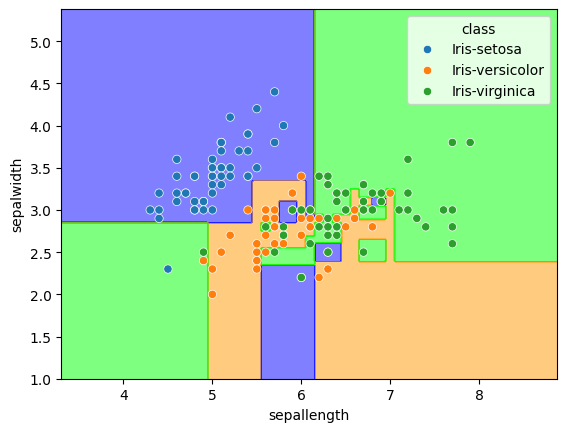

In [30]:

import numpy as np
from matplotlib.colors import LinearSegmentedColormap

colors = [(0, 0, 1), (1, 0.6, 0), (0, 1, 0)]
cm = LinearSegmentedColormap.from_list(
        'custom', colors, N=3)

x_min, x_max = X_train['sepallength'].min() - 1, X_train['sepallength'].max() + 1
y_min, y_max = X_train['sepalwidth'].min() - 1, X_train['sepalwidth'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = np.argmax(dt_clf.predict(np.c_[xx.ravel(), yy.ravel()]), axis=1)
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.5, cmap=cm)

sns.scatterplot(x='sepallength', y='sepalwidth', data=df, hue='class')
plt.show()

**ANTWORT:**
Das Schaubild visualisiert die Entscheidungsgrenzen des Decision Tree Klassifikators im zweidimensionalen Raum der Features sepallength und sepalwidth

Punkte: Zeigen die tatsächlichen Iris-Datenpunkte (nach Art eingefärbt)
Farbiger Hintergrund: Stellt die vom Klassifikator vorhergesagte Klasse für jeden möglichen Punkt im Raum dar

Die Merkmale des Decisions Trees spiegeln sich deutlich in der Form der Entscheidungsgrenzen wider:

Achsenparallele Grenzen: Entscheidungsbäume teilen den Raum nur mit geraden Linien, die parallel zu den Achsen verlaufen (z.B. sepallength > 5.8). Dies führt zu rechteckigen Unterteilungen
Segmentierung: Der gesamte Feature-Raum wird in klare, rechteckige Regionen zerlegt. Jede Region entspricht einem Endknoten (Blatt) des Baumes und wird einer einzigen Klasse zugeordnet.
Hohe Komplexität: Die Grenzflächen können sehr gezackt und komplex sein, da der Baum versucht, auch einzelne Datenpunkte korrekt zu klassifizieren (Hinweis auf potenzielles Overfitting).

## 4. Random Forest und Metriken

Ein Random Forest Klassifikator setzt sich aus mehreren Decision Trees zusammen. Beim Prädizieren wird die finale Klasse durch eine Mehrheitsentscheidung festgelegt.

a) Lies den Datensatz *3d_printer.csv* mit pandas ein und teile den Datensatz in Testset und Trainingsset auf. Das Label/die Zielgröße soll dabei die Spalte *material* sein. Transfomiere dieses mal die kategorischen Spalten *infill_pattern* und *material* mit dem ```LabelBinarizer``` von *scikit-learn* und dessen Methode ```fit_transform()```.

In [44]:
from sklearn.preprocessing import LabelBinarizer

df_3d = pd.read_csv('3d_printer.csv')

df_3d.head()

,layer_height,wall_thickness,infill_density,infill_pattern,nozzle_temperature,bed_temperature,print_speed,material,fan_speed,roughness,tension_strenght,elongation
0,0.02,8,90,grid,220,60,40,abs,0,25,18,1.2
1,0.02,7,90,honeycomb,225,65,40,abs,25,32,16,1.4
2,0.02,1,80,grid,230,70,40,abs,50,40,8,0.8
3,0.02,4,70,honeycomb,240,75,40,abs,75,68,10,0.5
4,0.02,6,90,grid,250,80,40,abs,100,92,5,0.7


In [46]:
y_binarizer = LabelBinarizer()
y = y_binarizer.fit_transform(df_3d['material'])

#print(y)

In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
infill_encoded_series = le.fit_transform(X['infill_pattern'])

X_clean = X.drop(columns=['infill_pattern'])

X_encoded = X_clean.reset_index(drop=True).copy()
X_encoded['infill_pattern_encoded'] = infill_encoded_series

X_encoded.head()

,layer_height,wall_thickness,infill_density,nozzle_temperature,bed_temperature,print_speed,fan_speed,roughness,tension_strenght,elongation,infill_pattern_encoded
0,0.02,8,90,220,60,40,0,25,18,1.2,0
1,0.02,7,90,225,65,40,25,32,16,1.4,1
2,0.02,1,80,230,70,40,50,40,8,0.8,0
3,0.02,4,70,240,75,40,75,68,10,0.5,1
4,0.02,6,90,250,80,40,100,92,5,0.7,0


In [52]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.25, random_state=42, stratify=y)

print(f"Features Training (X_train): {X_train.shape}")
print(f"Klassen Training (y_train): {y_train.shape}")

Features Training (X_train): (37, 11)
Klassen Training (y_train): (37, 1)


b) Importiere den Random Forest Klassifikator der *scikit-learn*-Bibliothek mit ```n_estimators=50``` und ```max_depth=3``` und trainiere diesen auf dem Datensatz.

In [53]:
from sklearn.ensemble import RandomForestClassifier

df_printer = pd.read_csv('3d_printer.csv')

In [54]:
y_binarizer = LabelBinarizer()
y = y_binarizer.fit_transform(df_printer['material'])

X = df_printer.drop(columns=['material'])

x_encoder = LabelEncoder()
infill_encoded = x_encoder.fit_transform(X['infill_pattern'])

X_clean = X.drop(columns=['infill_pattern'])
X_encoded = X_clean.reset_index(drop=True).copy()
X_encoded['infill_pattern_encoded'] = infill_encoded

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.25, random_state=42, stratify=y)

In [61]:
rf_model = RandomForestClassifier(n_estimators=50, max_depth=3)

rf_model.fit(X_train, y_train)

print(f"Random Forest Klassifikator trainiert")
print(f"   -> n_estimators (Anzahl Bäume): {rf_model.n_estimators}")
print(f"   -> max_depth (Maximale Tiefe): {rf_model.max_depth}")
print(f"   -> Trainiert auf {X_train.shape[0]} Instanzen.")

Random Forest Klassifikator trainiert
   -> n_estimators (Anzahl Bäume): 50
   -> max_depth (Maximale Tiefe): 3
   -> Trainiert auf 37 Instanzen.


/Users/alimounir/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Die Accuracy eine Klassifikators ist nur eine vielen Metriken, mit denen sich die Qualität eines Models messen lässt. Für Datensätze mit einer sehr ungleichen Klassenverteilung kann die Accuracy hoch sein, da der Klassifikator meist die häufigere Klasse prädiziert. Aus der Accuracy kann dann jedoch keine Aussage über die Fähigkeiten des Modells bezüglich der kleineren Klasse getroffen werden. Für diesen Fall wählt man häufig die Metriken Precision und Recall. Die Precision ist definiert als $$ \text{Precision} = \frac{\text{TP}}{\text{TP + FP}}$$ Der Recall ist gegeben durch $$ \text{Recall} = \frac{\text{TP}}{\text{TP + FN}}$$

c) Berechne Precision und Recall für obigen Klassifikator mithilfe der eingebauten scikit Funktionen.

In [62]:
from sklearn.metrics import precision_score, recall_score

y_pred = rf_model.predict(X_test)


precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)

recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)

print("--- Precision & Recall für Random Forest ---")
print(f"Accuracy (Score-Methode): {rf_model.score(X_test, y_test):.4f}")
print(f"Precision (Makro-Durchschnitt): {precision_macro:.4f}")
print(f"Recall (Makro-Durchschnitt): {recall_macro:.4f}")

--- Precision & Recall für Random Forest ---
Accuracy (Score-Methode): 1.0000
Precision (Makro-Durchschnitt): 1.0000
Recall (Makro-Durchschnitt): 1.0000


## 5. Support Vector Machine

Die Support Vector Machine versucht eine Hyperebene zu finden, die einen gegebenen Datensatz bestmöglich trennt:
<br>
<img src="2_classes_svm.png" alt="2 Klassen" width="300"/>

Diese Hyperebene ist definiert über einen Normalenvektor $\mathbf{w}$, der durch den Ursprung verläuft und einen Abstand zum Ursprung $b$. Ziel ist es also $\mathbf{w}$ und $b$ so zu wählen, dass der Datensatz möglichst eindeutig getrennt werden kann. Punkte auf der Hyperebene erfüllen die Ebenengleichung
$$ \mathbf{w} \cdot \mathbf{x} + b = 0.$$
Für Punkte links oder rechts der Hyperebene gilt
$$ \mathbf{w} \cdot \mathbf{x} + b < 0 \quad \text{bzw.} \quad \mathbf{w} \cdot \mathbf{x} + b > 0 .$$
Für zwei Klassen kann dann eine Klassifikation mittels $y_i = \text{sgn}(\mathbf{w} \cdot \mathbf{x}_i + b)$ erfolgen. Der Abstand zwischen Datenpunkten und Hyperebene ist dann maximal, wenn der Betrag von $\mathbf{w}$ minimal ist unter der Nebenbedingung, dass sich möglichst alle Datenpunkte auf der korrekten Seite der Hyperebene befinden, geschrieben als $y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1$. Dies führt zu dem Optimierungsproblem
$$ L(\mathbf{w}, b, \lambda) = \frac{1}{2} ||\mathbf{w}||^2 - \sum_{i=1}^N \lambda_i (y_i (\mathbf{w} \cdot \mathbf{x}_i + b)-1) $$

Im Realfall lässt sich ein Datensatz meist nicht perfekt sauber trennen. Um das Minimierungsproblem trotzdem lösen zu können wird daher noch ein Term mit Schlupfvariablen $\xi_i$ eingeführt, der die strenge Minimierung auflockert und mit einer positiven Konstante $C$ skaliert wird:
$$ C \sum_{i=1}^N\xi_i$$

a) Im unteren Block wird ein synthetischer Datensatz aus einer Sinus-Funktion und Rauschen konstruiert. Plotte den Datensatz mithilfe von *matplotlib* oder *seaborn*.

In [58]:
X = np.linspace(0,4,100).reshape(-1, 1)
y = np.sin(X)+ np.random.uniform(low=-0.3, high=0.3, size=X.shape)

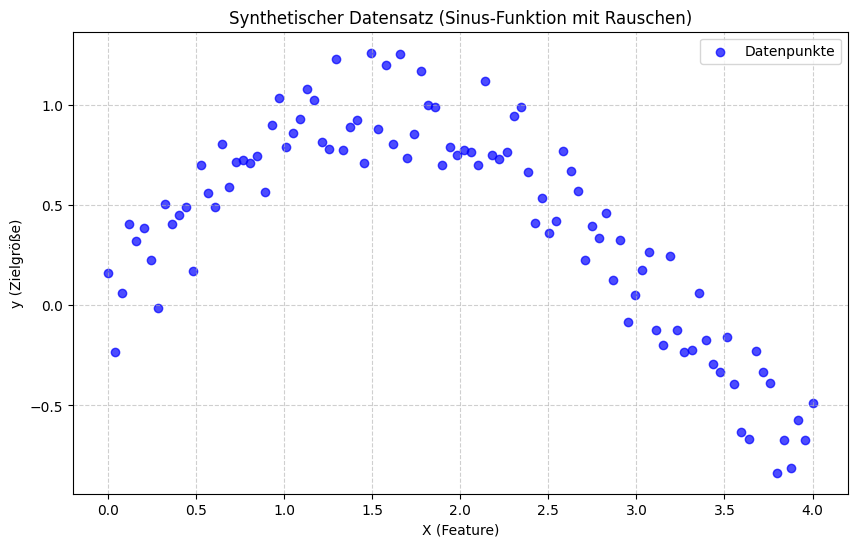

In [63]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Datenpunkte')
plt.title('Synthetischer Datensatz (Sinus-Funktion mit Rauschen)')
plt.xlabel('X (Feature)')
plt.ylabel('y (Zielgröße)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

b) Importiere den Support Vector Regressor der *scikit-learn*-Bibliothek und initialiere eine Instanz dieser Klasse. Nimm wieder einen Train-Test-Split vor und trainiere den Regressor auf den Trainingsdaten. Prädiziere nun auf den Testdatensatz und stelle die vorhergesagten Werte sowie den ursprünglichen Datensatz in einem Diagramm dar. Wähle für die Support Vector Machine die Option ```C``` manuell. Wähle dabei für ```C``` die Werte 0.01, 10 und 1000. Was funktioniert am besten? 

In [64]:
from sklearn.svm import SVR

X_train, X_test, y_train, y_test = train_test_split(X, y.ravel(), test_size=0.25)

C_values = [0.01, 10, 1000]
predictions = {}
models = {}
scores = {}

In [65]:
for C in C_values:

    svr = SVR(kernel='rbf', C=C)
    
    svr.fit(X_train, y_train)
    models[C] = svr
    
    y_pred_full = svr.predict(X) 
    predictions[C] = y_pred_full
    
    scores[C] = svr.score(X_test, y_test)

print("--- R^2 Scores auf dem Testset ---")

for C, score in scores.items():
    print(f"C={C:<5}: R^2 Score = {score:.4f}")

--- R^2 Scores auf dem Testset ---
C=0.01 : R^2 Score = 0.3712
C=10   : R^2 Score = 0.8122
C=1000 : R^2 Score = 0.7948


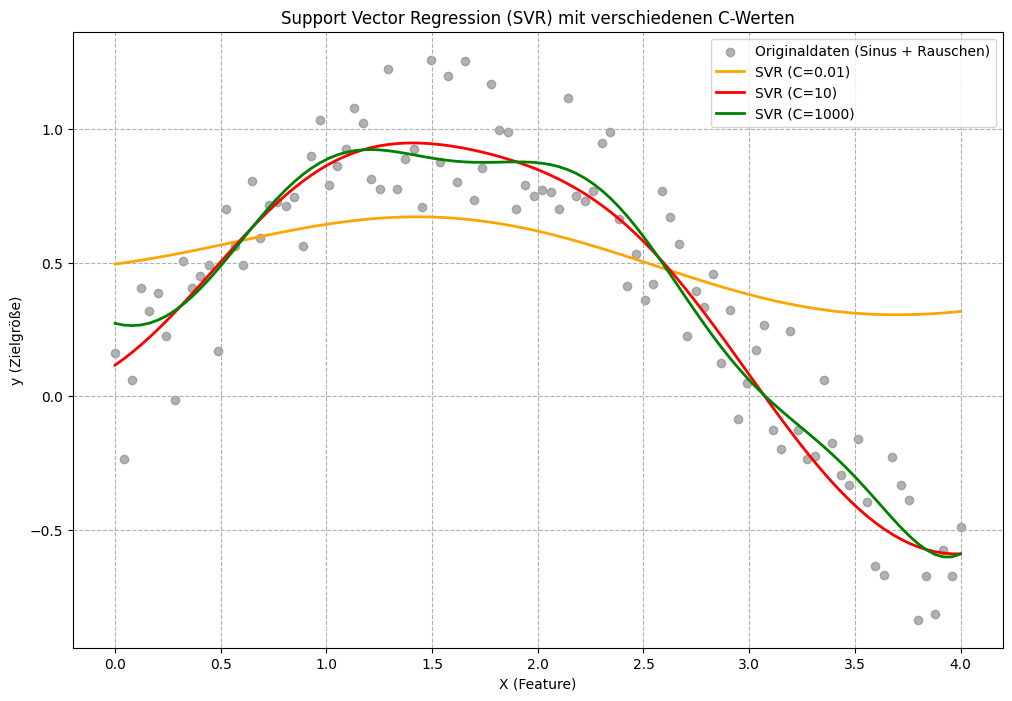

In [66]:
plt.figure(figsize=(12, 8))

plt.scatter(X, y, label='Originaldaten (Sinus + Rauschen)', color='gray', alpha=0.6)

colors = ['orange', 'red', 'green']
for C, color in zip(C_values, colors):
    plt.plot(X, predictions[C], label=f'SVR (C={C})', color=color, linewidth=2)

plt.title('Support Vector Regression (SVR) mit verschiedenen C-Werten')
plt.xlabel('X (Feature)')
plt.ylabel('y (Zielgröße)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

c) Wir wollen nun versuchen, den $y$-Wert zu einem einzelnen Datenpunkt vorherzusagen. Prädiziere mit deinem Regressor den $y$-Wert zu einem Wert von $x>4$ und vergleiche es mit $\sin (x)$. Was fällt dir auf? Wie kommt der Unterschied zustande? Tipp: Die ```predict()```-Methode benötigt einen Wert in der Form ``` predict([[5]])```

In [68]:
import math

svr_best = models[10] 

x_new = 5.0
y_pred_extrapolated = svr_best.predict([[x_new]])[0]

y_true_sin = math.sin(x_new)

print(f"--- Extrapolation für x = {x_new} ---")
print(f"SVR-Vorhersage (y_pred): {y_pred_extrapolated:.4f}")
print(f"Tatsächlicher Sinus-Wert (sin(x)): {y_true_sin:.4f}")
print(f"Differenz: {abs(y_true_sin - y_pred_extrapolated):.4f}")

--- Extrapolation für x = 5.0 ---
SVR-Vorhersage (y_pred): -0.1091
Tatsächlicher Sinus-Wert (sin(x)): -0.9589
Differenz: 0.8498


**Was fällt auf?** die SVR-Vorhersage ($\mathbf{y}_{\text{pred}}$) deutlich vom tatsächlichen Wert der Sinusfunktion ($\mathbf{\sin(x)}$) abweicht und meistens nahe Null. Der Wert der Vorhersage liegt typischerweise nahe dem letzten Wert des $y$-Bereichs, den der Regressor im Trainingsset gesehen hat, oder nahe dem Durchschnitt der Support-Vektoren am Ende des Trainingsbereichs ($x \approx 4$).

**Wie kommt der Unterschied zustande?** Dieser Unterschied entsteht weil die SVR insbesondere mit einem RBF-Kernel keine Extrapolation  durchführen kann sondern nur Interpolation. Stattdessen wird die Vorhersage zu einem konstanten Wert (dem Bias-Term $b$). Das SVR-Modell "weiß" nicht was nach $x=4$ passiert und fällt auf einen konservativen Standardwert zurück anstatt dem Sinus-Trend fortzusetzen

#### Klassifikation mit SVM

In den folgenden Blöcken ist das Training einer Support Vector Machine zur Klassifikation des Moon-Datensatzes implementiert. Führe die Codeblöcke zunächst aus und versuche, alle Trainingsschritte nachzuvollziehen. Erhöhe jetzt die Anzahl der Trainingspunkte (bis maximal 10000). Was fällt dir beim Training auf? Miss die Dauer des Trainings mithilfe der Python-Module `time` oder `datetime` und plotte die Trainingsdauer in Abhängigkeit der Anzahl an Datenpunkten. Welches Verhalten kannst du erkennen?

In [69]:
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import numpy as np


noisy_moons, labels = datasets.make_moons(n_samples=200, noise=.2)
X_train, X_test, y_train, y_test = train_test_split(noisy_moons, labels, test_size=0.25)


clf = SVC()
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

def make_meshgrid(x, y, h=.02):
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

/var/folders/h1/7s_jyhrs0gd118jm5hmk18lw0000gn/T/ipykernel_42352/1860662408.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


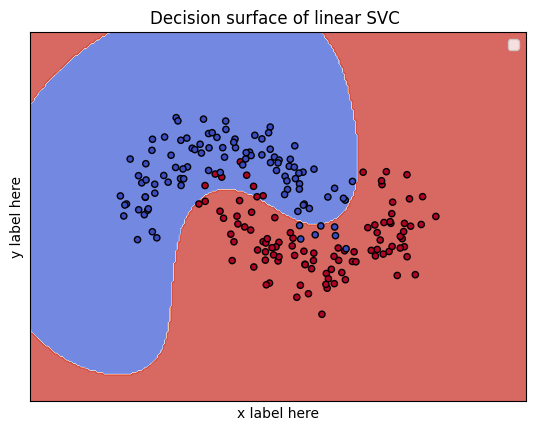

In [70]:
fig, ax = plt.subplots()
# title for the plots
title = ('Decision surface of linear SVC ')
# Set-up grid for plotting.
X0, X1 = noisy_moons[:, 0], noisy_moons[:, 1]
xx, yy = make_meshgrid(X0, X1)

plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax.scatter(X0, X1, c=labels, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
ax.set_ylabel('y label here')
ax.set_xlabel('x label here')
ax.set_xticks(())
ax.set_yticks(())
ax.set_title(title)
ax.legend()
plt.show()

n_samples=200  : Trainingszeit = 0.0029 Sekunden
n_samples=500  : Trainingszeit = 0.0021 Sekunden
n_samples=1000 : Trainingszeit = 0.0051 Sekunden
n_samples=2000 : Trainingszeit = 0.0103 Sekunden
n_samples=4000 : Trainingszeit = 0.0335 Sekunden
n_samples=6000 : Trainingszeit = 0.0536 Sekunden
n_samples=8000 : Trainingszeit = 0.0996 Sekunden
n_samples=10000: Trainingszeit = 0.1296 Sekunden


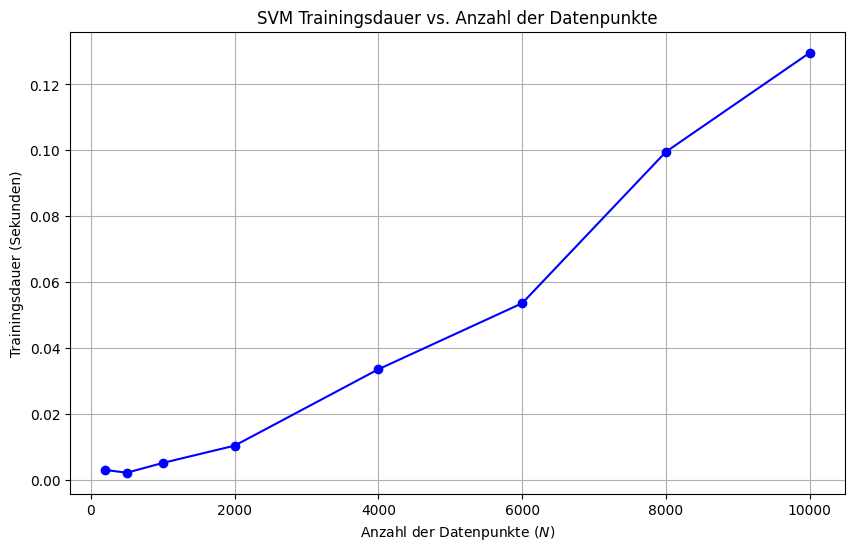

In [72]:
import time
n_samples_list = [200, 500, 1000, 2000, 4000, 6000, 8000, 10000]
training_times = []

for n_samples in n_samples_list:

    X, y = datasets.make_moons(n_samples=n_samples, noise=.2)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    clf = SVC(random_state=42)
    start_time = time.time()
    
    clf.fit(X_train, y_train)
    
    end_time = time.time()
    duration = end_time - start_time
    training_times.append(duration)
    
    print(f"n_samples={n_samples:<5}: Trainingszeit = {duration:.4f} Sekunden")

plt.figure(figsize=(10, 6))
plt.plot(n_samples_list, training_times, marker='o', linestyle='-', color='blue')
plt.title('SVM Trainingsdauer vs. Anzahl der Datenpunkte')
plt.xlabel('Anzahl der Datenpunkte ($N$)')
plt.ylabel('Trainingsdauer (Sekunden)')
plt.grid(True)
plt.show()

**Was fällt beim Training auf?**
Wenn die Anzahl der Trainingspunkte erhöht wird:

* Accuracy: Die Genauigkeit der SVM auf dem Testset steigt leicht an oder bleibt konstant da das Modell mehr Daten zur Definition der optimalen Hyperebene erhält

* Trainingszeit: Die Zeit, die für die Methode clf.fit() benötigt wird, erhöht sich deutlich mit der Anzahl der Datenpunkte.

**Welches Verhalten ist erkennbar?**
Die Trainingsdauer der SVM überproportional zur Anzahl der Datenpunkte ($N$) wächst.
* Verhalten: Die Trainingsdauer wächst in etwa exponential der Anzahl der Trainingspunkte.
* Obwohl die finale Hyperebene nur von den Support-Vektoren abhängt, müssen im Training zunächst alle $N$ Punkte in die Optimierung einbezogen werden, was die quadratische Komplexität verursacht.